In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

from statsmodels.graphics.gofplots import qqplot

In [8]:
DATA_DIR = Path("../Data")

RESULTS_FILE = DATA_DIR / "results_df.csv"
PRE_EVENT_FILE = DATA_DIR / "pre_event_df.csv"
ETH_WINDOW_FILE = DATA_DIR / "eth_return_df.csv"
CRIX_WINDOW_FILE = DATA_DIR / "crix_return_df.csv"
ETH_AR_FILE = DATA_DIR / "eth_abnormal_return_df.csv"

NUM_PERMUTATIONS = 1_000
RANDOM_SEED = 42

In [9]:
required_files = [
    RESULTS_FILE,
    PRE_EVENT_FILE,
    ETH_WINDOW_FILE,
    CRIX_WINDOW_FILE,
    ETH_AR_FILE,
]

missing_files = [
    file_path
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following files were not found:\n"
        + "\n".join(str(path) for path in missing_files)
    )

print("All required files were found.")

All required files were found.


In [10]:
results_df = pd.read_csv(
    RESULTS_FILE,
)

# Remove automatically saved pandas index columns
results_df = results_df.loc[
    :,
    ~results_df.columns.str.startswith("Unnamed")
]

# Repair a possible accidental "index" column
if (
    "event_date" not in results_df.columns
    and "index" in results_df.columns
):
    results_df = results_df.rename(
        columns={"index": "event_date"}
    )

if "event_date" not in results_df.columns:
    raise KeyError(
        "results_df must contain an 'event_date' column. "
        f"Available columns: {results_df.columns.tolist()}"
    )

results_df["event_date"] = pd.to_datetime(
    results_df["event_date"],
    errors="coerce",
).dt.normalize()

results_df = results_df.dropna(
    subset=["event_date"]
)

results_df.head()

,event_date,alpha,beta,residual_std,n_obs,r_squared
0,2017-10-16,-0.002077,0.035590,0.046221,31,0.002368
1,2019-02-28,0.003345,0.878809,0.024526,31,0.448151
2,2019-12-08,-0.002807,0.545510,0.020911,31,0.297934
3,2020-01-02,-0.003677,0.214412,0.020320,31,0.072192
4,2020-10-14,-0.000630,0.408600,0.022845,31,0.119865


In [11]:
def load_event_window_csv(file_path):
    """
    Load a saved event-window DataFrame.

    Expected structure:
        relative_day, 2017-10-16, 2019-02-28, ...
        -3,            ...
        -2,            ...
         0,            ...
    """
    df = pd.read_csv(file_path)

    # Remove automatically saved pandas index columns
    df = df.loc[
        :,
        ~df.columns.str.startswith("Unnamed")
    ]

    if df.empty:
        raise ValueError(
            f"{file_path} is empty."
        )

    # The first remaining column should be the relative-day index
    first_column = df.columns[0]

    df = df.set_index(first_column)

    df.index = pd.to_numeric(
        df.index,
        errors="coerce",
    )

    if df.index.isna().any():
        raise ValueError(
            f"Could not convert the index of {file_path} "
            "to relative event days."
        )

    df.index = df.index.astype(int)
    df.index.name = "relative_day"

    # Convert event-date columns to normalized timestamps
    df.columns = pd.DatetimeIndex(
        pd.to_datetime(df.columns)
    ).normalize()

    # Convert values to numeric
    df = df.apply(
        pd.to_numeric,
        errors="coerce",
    )

    return df

In [12]:
pre_event_df = load_event_window_csv(
    PRE_EVENT_FILE
)

eth_return_df = load_event_window_csv(
    ETH_WINDOW_FILE
)

crix_return_df = load_event_window_csv(
    CRIX_WINDOW_FILE
)

eth_ar_df = load_event_window_csv(
    ETH_AR_FILE
)

In [13]:
print("results_df:", results_df.shape)
print("pre_event_df:", pre_event_df.shape)
print("eth_return_df:", eth_return_df.shape)
print("crix_return_df:", crix_return_df.shape)
print("eth_ar_df:", eth_ar_df.shape)

print("\nresults_df columns:")
print(results_df.columns.tolist())

print("\nPre-event index:")
print(pre_event_df.index.tolist())

print("\nETH event dates:")
print(
    eth_return_df.columns
    .strftime("%Y-%m-%d")
    .tolist()
)

results_df: (14, 6)
pre_event_df: (31, 13)
eth_return_df: (25, 14)
crix_return_df: (25, 14)
eth_ar_df: (25, 14)

results_df columns:
['event_date', 'alpha', 'beta', 'residual_std', 'n_obs', 'r_squared']

Pre-event index:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

ETH event dates:
['2017-10-16', '2019-02-28', '2019-12-08', '2020-01-02', '2020-10-14', '2020-12-01', '2021-04-15', '2021-08-05', '2021-10-27', '2021-12-09', '2022-06-30', '2022-09-06', '2022-09-15', '2024-03-13']


In [14]:
regression_events = pd.DatetimeIndex(
    results_df["event_date"]
)

valid_events = (
    regression_events
    .intersection(pre_event_df.columns)
    .intersection(eth_return_df.columns)
    .intersection(crix_return_df.columns)
    .intersection(eth_ar_df.columns)
)

if len(valid_events) == 0:
    raise ValueError(
        "No common event dates were found across the saved files."
    )

results_aligned = (
    results_df
    .set_index("event_date")
    .loc[valid_events]
)

pre_event_df = pre_event_df.loc[
    :,
    valid_events
]

eth_return_df = eth_return_df.loc[
    :,
    valid_events
]

crix_return_df = crix_return_df.loc[
    :,
    valid_events
]

eth_ar_df = eth_ar_df.loc[
    :,
    valid_events
]

print("Valid events:")
print(
    valid_events
    .strftime("%Y-%m-%d")
    .tolist()
)

Valid events:
['2019-02-28', '2019-12-08', '2020-01-02', '2020-10-14', '2020-12-01', '2021-04-15', '2021-08-05', '2021-10-27', '2021-12-09', '2022-06-30', '2022-09-06', '2022-09-15', '2024-03-13']


In [16]:
def calculate_pre_event_std(
    pre_event_df,
    degrees_of_freedom_adjustment=2,
):
    """
    Calculate event-specific residual standard deviations.
    """
    n_obs = len(pre_event_df)

    denominator = (
        n_obs
        - degrees_of_freedom_adjustment
    )

    if denominator <= 0:
        raise ValueError(
            "The pre-event sample is too small."
        )

    centered_residuals = (
        pre_event_df
        - pre_event_df.mean(axis=0)
    )

    variance = (
        centered_residuals.pow(2).sum(axis=0)
        / denominator
    )

    return np.sqrt(variance)

In [17]:
std_ar = calculate_pre_event_std(
    pre_event_df
)

std_ar

2019-02-28    0.024526
2019-12-08    0.020911
2020-01-02    0.020320
2020-10-14    0.022845
2020-12-01    0.026339
2021-04-15    0.025328
2021-08-05    0.028724
2021-10-27    0.026793
2021-12-09    0.024193
2022-06-30    0.037778
2022-09-06    0.031897
2022-09-15    0.035825
2024-03-13    0.014869
dtype: float64

In [18]:
def calculate_car_t_test(
    abnormal_return_df,
    std_ar,
):
    """
    Compute CAR, standard error, t-statistic, and
    two-sided p-value for each event.
    """
    rows = []

    for event_date in abnormal_return_df.columns:

        data = (
            abnormal_return_df[event_date]
            .dropna()
            .to_numpy()
        )

        car = data.sum()
        n_obs = len(data)
        residual_std = std_ar.loc[event_date]

        if n_obs < 2:
            standard_error = np.nan
            t_stat = np.nan
            p_value = np.nan

        elif (
            not np.isfinite(residual_std)
            or residual_std <= 0
        ):
            standard_error = np.nan
            t_stat = np.nan
            p_value = np.nan

        else:
            standard_error = (
                residual_std
                / np.sqrt(n_obs)
            )

            t_stat = car / standard_error

            p_value = 2 * stats.t.sf(
                np.abs(t_stat),
                df=n_obs - 1,
            )

        rows.append(
            {
                "event_date": event_date,
                "car": car,
                "std_ar": residual_std,
                "standard_error": standard_error,
                "t_stat": t_stat,
                "p_value": p_value,
                "n_obs": n_obs,
            }
        )

    combined_stats = pd.DataFrame(rows)

    combined_stats[
        [
            "car",
            "std_ar",
            "standard_error",
            "t_stat",
            "p_value",
        ]
    ] = combined_stats[
        [
            "car",
            "std_ar",
            "standard_error",
            "t_stat",
            "p_value",
        ]
    ].round(3)

    return combined_stats

In [19]:
t_result = calculate_car_t_test(
    abnormal_return_df=eth_ar_df,
    std_ar=std_ar,
)

t_result

,event_date,car,std_ar,standard_error,t_stat,p_value,n_obs
0,2019-02-28,-0.247,0.025,0.005,-50.357,0.000,25
1,2019-12-08,-0.048,0.021,0.004,-11.455,0.000,25
2,2020-01-02,0.273,0.020,0.004,67.150,0.000,25
3,2020-10-14,-0.014,0.023,0.005,-2.983,0.006,25
4,2020-12-01,-0.121,0.026,0.005,-23.044,0.000,25
5,2021-04-15,0.369,0.025,0.005,72.893,0.000,25
6,2021-08-05,-0.019,0.029,0.006,-3.317,0.003,25
7,2021-10-27,0.026,0.027,0.005,4.888,0.000,25
8,2021-12-09,-0.141,0.024,0.005,-29.233,0.000,25
9,2022-06-30,0.452,0.038,0.008,59.828,0.000,25


In [20]:
def permutation_test(
    pre_event_df,
    event_df,
    num_permutations=1_000,
    random_seed=42,
):
    """
    Shuffle pre-event and event abnormal returns together,
    then compare permuted CARs with the observed CAR.
    """
    if not pre_event_df.columns.equals(
        event_df.columns
    ):
        raise ValueError(
            "pre_event_df and event_df must have identical "
            "event-date columns."
        )

    rng = np.random.default_rng(
        random_seed
    )

    permutation_rows = []
    summary_rows = []

    for event_date in pre_event_df.columns:

        pre_event_data = (
            pre_event_df[event_date]
            .dropna()
            .to_numpy()
        )

        event_data = (
            event_df[event_date]
            .dropna()
            .to_numpy()
        )

        if len(event_data) == 0:
            continue

        actual_car = event_data.sum()

        combined_data = np.concatenate(
            [
                pre_event_data,
                event_data,
            ]
        )

        null_distribution = np.empty(
            num_permutations
        )

        for i in range(num_permutations):

            shuffled_data = rng.permutation(
                combined_data
            )

            pseudo_event_data = shuffled_data[
                :len(event_data)
            ]

            null_distribution[i] = (
                pseudo_event_data.sum()
            )

        # Plus-one correction prevents a zero p-value
        p_value = (
            1
            + np.sum(
                null_distribution >= actual_car
            )
        ) / (
            num_permutations + 1
        )

        for permutation_number, permuted_car in enumerate(
            null_distribution,
            start=1,
        ):
            permutation_rows.append(
                {
                    "event_date": event_date,
                    "permutation": permutation_number,
                    "permuted_car": permuted_car,
                }
            )

        summary_rows.append(
            {
                "event_date": event_date,
                "actual_car": actual_car,
                "p_value": p_value,
                "n_pre_event": len(pre_event_data),
                "n_event": len(event_data),
            }
        )

    permutation_results_df = pd.DataFrame(
        permutation_rows
    )

    summary_df = pd.DataFrame(
        summary_rows
    )

    return (
        permutation_results_df,
        summary_df,
    )

In [21]:
perm_results_df, perm_summary_df = permutation_test(
    pre_event_df=pre_event_df,
    event_df=eth_ar_df,
    num_permutations=NUM_PERMUTATIONS,
    random_seed=RANDOM_SEED,
)

perm_summary_df

,event_date,actual_car,p_value,n_pre_event,n_event
0,2019-02-28,-0.247007,0.916084,31,25
1,2019-12-08,-0.047906,0.654346,31,25
2,2020-01-02,0.272894,0.025974,31,25
3,2020-10-14,-0.013629,0.520480,31,25
4,2020-12-01,-0.121394,0.771229,31,25
5,2021-04-15,0.369248,0.050949,31,25
6,2021-08-05,-0.019057,0.546454,31,25
7,2021-10-27,0.026193,0.447552,31,25
8,2021-12-09,-0.141450,0.802198,31,25
9,2022-06-30,0.452034,0.031968,31,25


In [22]:
def wilcoxon_signed_rank_test(
    pre_event_df,
    event_df,
):
    """
    Wilcoxon signed-rank test comparing pre-event and
    event-window abnormal returns for each event.
    """
    if not pre_event_df.columns.equals(
        event_df.columns
    ):
        raise ValueError(
            "pre_event_df and event_df must have identical "
            "event-date columns."
        )

    rows = []

    for event_date in pre_event_df.columns:

        pre_event_data = (
            pre_event_df[event_date]
            .dropna()
            .to_numpy()
        )

        event_data = (
            event_df[event_date]
            .dropna()
            .to_numpy()
        )

        n_obs = min(
            len(pre_event_data),
            len(event_data),
        )

        if n_obs == 0:
            statistic = np.nan
            p_value = np.nan

        else:
            pre_event_data = pre_event_data[
                :n_obs
            ]

            event_data = event_data[
                :n_obs
            ]

            try:
                test_result = wilcoxon(
                    pre_event_data,
                    event_data,
                )

                statistic = test_result.statistic
                p_value = test_result.pvalue

            except ValueError:
                statistic = np.nan
                p_value = np.nan

        rows.append(
            {
                "event_date": event_date,
                "statistic": statistic,
                "p_value": p_value,
                "n_obs": n_obs,
            }
        )

    return pd.DataFrame(rows)

In [23]:
wilcoxon_df = wilcoxon_signed_rank_test(
    pre_event_df=pre_event_df,
    event_df=eth_ar_df,
)

wilcoxon_df

,event_date,statistic,p_value,n_obs
0,2019-02-28,142.0,0.596500,25
1,2019-12-08,139.0,0.542404,25
2,2020-01-02,107.0,0.140915,25
3,2020-10-14,153.0,0.811930,25
4,2020-12-01,154.0,0.832509,25
5,2021-04-15,109.0,0.156338,25
6,2021-08-05,161.0,0.978915,25
7,2021-10-27,154.0,0.832509,25
8,2021-12-09,129.0,0.380984,25
9,2022-06-30,97.0,0.080196,25


In [24]:
def standardize(series):
    """
    Z-score standardization.
    """
    series = pd.Series(series).dropna()

    if series.std() == 0:
        raise ValueError(
            "Cannot standardize a constant series."
        )

    return (
        series - series.mean()
    ) / series.std()

In [25]:
residuals = (
    pre_event_df
    .stack()
    .rename("residual")
    .dropna()
)

resid_standardized = standardize(
    residuals
)

resid_standardized.head()

relative_day            
0             2019-02-28   -0.355876
              2019-12-08   -0.149344
              2020-01-02    1.153385
              2020-10-14    0.193187
              2020-12-01   -0.480260
Name: residual, dtype: float64

In [26]:
def plot_qq(
    residuals,
    axis_range=(-5, 5),
    save_path=None,
):
    """
    QQ plot comparing standardized residuals
    with theoretical normal quantiles.
    """
    plt.rcParams["font.family"] = "serif"

    residuals = (
        pd.Series(residuals)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    fig, ax = plt.subplots(
        figsize=(5, 5)
    )

    qqplot(
        residuals,
        line="s",
        ax=ax,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1,
        markersize=5,
    )

    ax.set_xlabel(
        "Theoretical quantiles",
        fontsize=12,
    )

    ax.set_ylabel(
        "Sample quantiles",
        fontsize=12,
    )

    ax.set_xlim(axis_range)
    ax.set_ylim(axis_range)

    ax.set_facecolor("none")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )

    plt.show()

    return fig

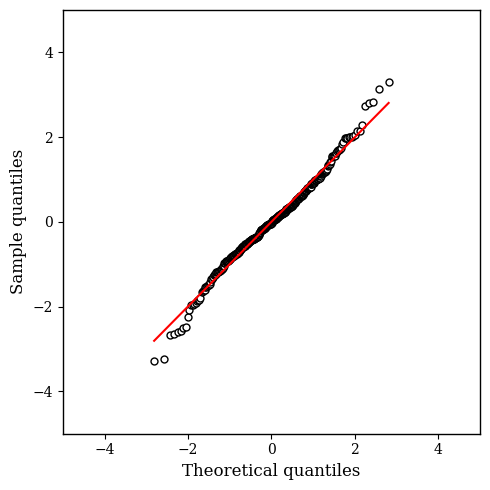

In [27]:
fig = plot_qq(
    residuals=resid_standardized,
    axis_range=(-5, 5),
    save_path="qq_plot.png",
)